In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import torch
from scipy.fft import fft, fftfreq, ifft, rfft, rfftfreq
from scipy.io import wavfile
from scipy.signal import find_peaks
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm.notebook import tqdm

In [2]:
DIR_PROJECT = "/home/mxadams/Dropbox/school_of_mines/CSCI575/project"
DIR_SRC = os.path.join(DIR_PROJECT, "CSCI575-project")
DIR_DATA = os.path.join(DIR_PROJECT, "Binary_Drone_Audio")
DIR_DRONE = os.path.join(DIR_DATA, "yes_drone")
DIR_UNKNOWN = os.path.join(DIR_DATA, "unknown")
NUM_FREQUENCIES = 8000
MODEL_CP_FILENAME = "model_cp.pth.tar"
LEARNING_RATE = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2**8
MAX_NUM_EPOCHS = 2**8
TRAIN_CONVERGE_WINDOW = 2**4
TRAIN_CONVERGE_STD = 0.001
TEST_FRAC = 0.2
RANDOM_SEED = 42
NUM_WORKERS = 12
PIN_MEMORY = True
# LOAD_MODEL = False

# Data

https://www.kaggle.com/datasets/amineipad/drone-sound-audio-detection

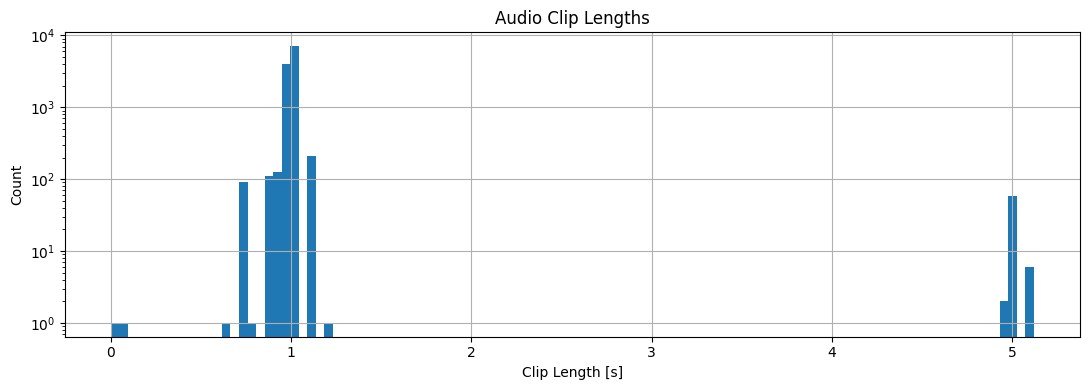

In [3]:
clip_lengths = np.array([])
sample_rates = np.array([])

for filename in os.listdir(DIR_DRONE):
    samplerate, data = wavfile.read(os.path.join(DIR_DRONE, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
    sample_rates = np.append(sample_rates, samplerate)

for filename in os.listdir(DIR_UNKNOWN):
    samplerate, data = wavfile.read(os.path.join(DIR_UNKNOWN, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
    sample_rates = np.append(sample_rates, samplerate)

plt.figure(figsize=(11, 4))
plt.hist(clip_lengths, bins=int(np.sqrt(len(clip_lengths))))
plt.title("Audio Clip Lengths")
plt.xlabel("Clip Length [s]")
plt.ylabel("Count")
plt.yscale("log")
plt.grid()
plt.tight_layout()

# Model Helper Functions

In [4]:
def wav_to_data(filepath, num_features: int = NUM_FREQUENCIES):
    samplerate, data = wavfile.read(filepath)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / max_val
    else:
        data = data.astype(np.float32)
    data = data - np.mean(data)
    fft_val = rfft(data)
    fft_mag = np.abs(fft_val)
    fft_freq = rfftfreq(len(data), d=1.0 / samplerate)
    target_freq = np.arange(1, num_features)
    features = np.interp(target_freq, fft_freq, fft_mag, left=0.0, right=0.0)
    features = np.log1p(features)
    return features.astype(np.float32)

In [5]:
def load_dataset(dir_drone, dir_unknown, num_features: int = NUM_FREQUENCIES):
    X = []
    y = []
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in os.listdir(folder):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath, num_features=num_features)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y

In [6]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    all_drone_probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(logits, dim=1)
            drone_probs = probs[:, 0]
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())
            all_drone_probs.append(drone_probs.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_drone_probs = torch.cat(all_drone_probs).numpy()
    avg_loss = test_loss / len(test_loader.dataset)
    drone_true = (all_labels == 0).astype(int)
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "drone_precision": precision_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_recall": recall_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_f1": f1_score(all_labels, all_preds, pos_label=0, zero_division=0),
        "drone_pr_auc": average_precision_score(drone_true, all_drone_probs),
        "confusion_matrix": confusion_matrix(all_labels, all_preds, labels=[0, 1]),
    }
    return metrics

# Model Definition

In [7]:
class NeuralNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(NUM_FREQUENCIES - 1, 2**12),
            torch.nn.ReLU(),
            torch.nn.Linear(2**12, 2**9),
            torch.nn.ReLU(),
            torch.nn.Linear(2**9, 2**6),
            torch.nn.ReLU(),
            torch.nn.Linear(2**6, 2**3),
            torch.nn.ReLU(),
            torch.nn.Linear(2**3, 2),
        )

    def forward(self, x):
        return self.network(x)

# Model Setup

In [8]:
X, y = load_dataset(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
dataset = TensorDataset(X, y)

In [9]:
X_np, y_np = load_dataset(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y_np
)
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)
)
# y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# class_counts = torch.bincount(y_train_tensor)
# class_weights = 1.0 / class_counts.float()
# sample_weights = class_weights[y_train_tensor]
# train_sampler = WeightedRandomSampler(
#     weights=sample_weights, num_samples=len(sample_weights), replacement=True
# )
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
)

In [10]:
model = NeuralNet().to(DEVICE)
train_labels = torch.tensor(
    [train_dataset[i][1].item() for i in range(len(train_dataset))]
)
class_counts = torch.bincount(train_labels, minlength=2)
loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Train Model

In [11]:
plot_data = {
    "epoch": np.array([0.0]),
    "train_loss": np.array([1.0]),
    "test_loss": np.array([1.0]),
    "accuracy": np.array([0.0]),
    "balanced_accuracy": np.array([0.0]),
    "precision": np.array([0.0]),
    "recall": np.array([0.0]),
    "f1-score": np.array([0.0]),
    "pr-auc": np.array([0.0]),
}
for epoch in range(MAX_NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)

    metrics = evaluate_model(
        model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
    )
    plot_data["epoch"] = np.append(plot_data["epoch"], epoch + 1)
    plot_data["train_loss"] = np.append(plot_data["train_loss"], avg_train_loss)
    plot_data["test_loss"] = np.append(plot_data["test_loss"], metrics["loss"])
    plot_data["accuracy"] = np.append(plot_data["accuracy"], metrics["accuracy"])
    plot_data["balanced_accuracy"] = np.append(
        plot_data["balanced_accuracy"], metrics["balanced_accuracy"]
    )
    plot_data["precision"] = np.append(
        plot_data["precision"], metrics["drone_precision"]
    )
    plot_data["recall"] = np.append(plot_data["recall"], metrics["drone_recall"])
    plot_data["f1-score"] = np.append(plot_data["f1-score"], metrics["drone_f1"])
    plot_data["pr-auc"] = np.append(plot_data["pr-auc"], metrics["drone_pr_auc"])

    print(
        f"Epoch {str(int(plot_data["epoch"][-1])).rjust(len(str(MAX_NUM_EPOCHS)))}/{MAX_NUM_EPOCHS}  |  "
        f"Train loss: {plot_data["train_loss"][-1]:.4f}  |  "
        f"Test loss: {plot_data["test_loss"][-1]:.4f}  |  "
        f"Acc: {plot_data["accuracy"][-1]:.4f}  |  "
        f"Bal acc: {plot_data["balanced_accuracy"][-1]:.4f}  |  "
        f"Prec: {plot_data["precision"][-1]:.4f}  |  "
        f"Rec: {plot_data["recall"][-1]:.4f}  |  "
        f"F1: {plot_data["f1-score"][-1]:.4f}  |  "
        f"PR-AUC: {plot_data["pr-auc"][-1]:.4f}"
    )
    if len(plot_data["balanced_accuracy"]) > 2 * TRAIN_CONVERGE_WINDOW:
        train_converge_std = plot_data["balanced_accuracy"][
            len(plot_data["balanced_accuracy"]) - TRAIN_CONVERGE_WINDOW :
        ].std()
        if train_converge_std < TRAIN_CONVERGE_STD:
            print("Balanced Accuracy STD Converged:", train_converge_std)
            break

  0%|          | 0/37 [00:00<?, ?it/s]

Epoch   1/256  |  Train loss: 0.5939  |  Test loss: 0.5421  |  Acc: 0.7245  |  Bal acc: 0.8151  |  Prec: 0.2834  |  Rec: 0.9323  |  F1: 0.4347  |  PR-AUC: 0.3353


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch   2/256  |  Train loss: 0.4695  |  Test loss: 0.4732  |  Acc: 0.7360  |  Bal acc: 0.8298  |  Prec: 0.2949  |  Rec: 0.9511  |  F1: 0.4502  |  PR-AUC: 0.4664


  0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch  46/256  |  Train loss: 0.0375  |  Test loss: 0.1026  |  Acc: 0.9889  |  Bal acc: 0.9741  |  Prec: 0.9478  |  Rec: 0.9549  |  F1: 0.9513  |  PR-AUC: 0.9708


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch  47/256  |  Train loss: 0.0363  |  Test loss: 0.1026  |  Acc: 0.9889  |  Bal acc: 0.9741  |  Prec: 0.9478  |  Rec: 0.9549  |  F1: 0.9513  |  PR-AUC: 0.9708


  0%|          | 0/37 [00:00<?, ?it/s]

Epoch  48/256  |  Train loss: 0.0351  |  Test loss: 0.1018  |  Acc: 0.9880  |  Bal acc: 0.9736  |  Prec: 0.9407  |  Rec: 0.9549  |  F1: 0.9478  |  PR-AUC: 0.9738
Balanced Accuracy STD Converged: 0.0009730042734511442


# Plot Model Metrics

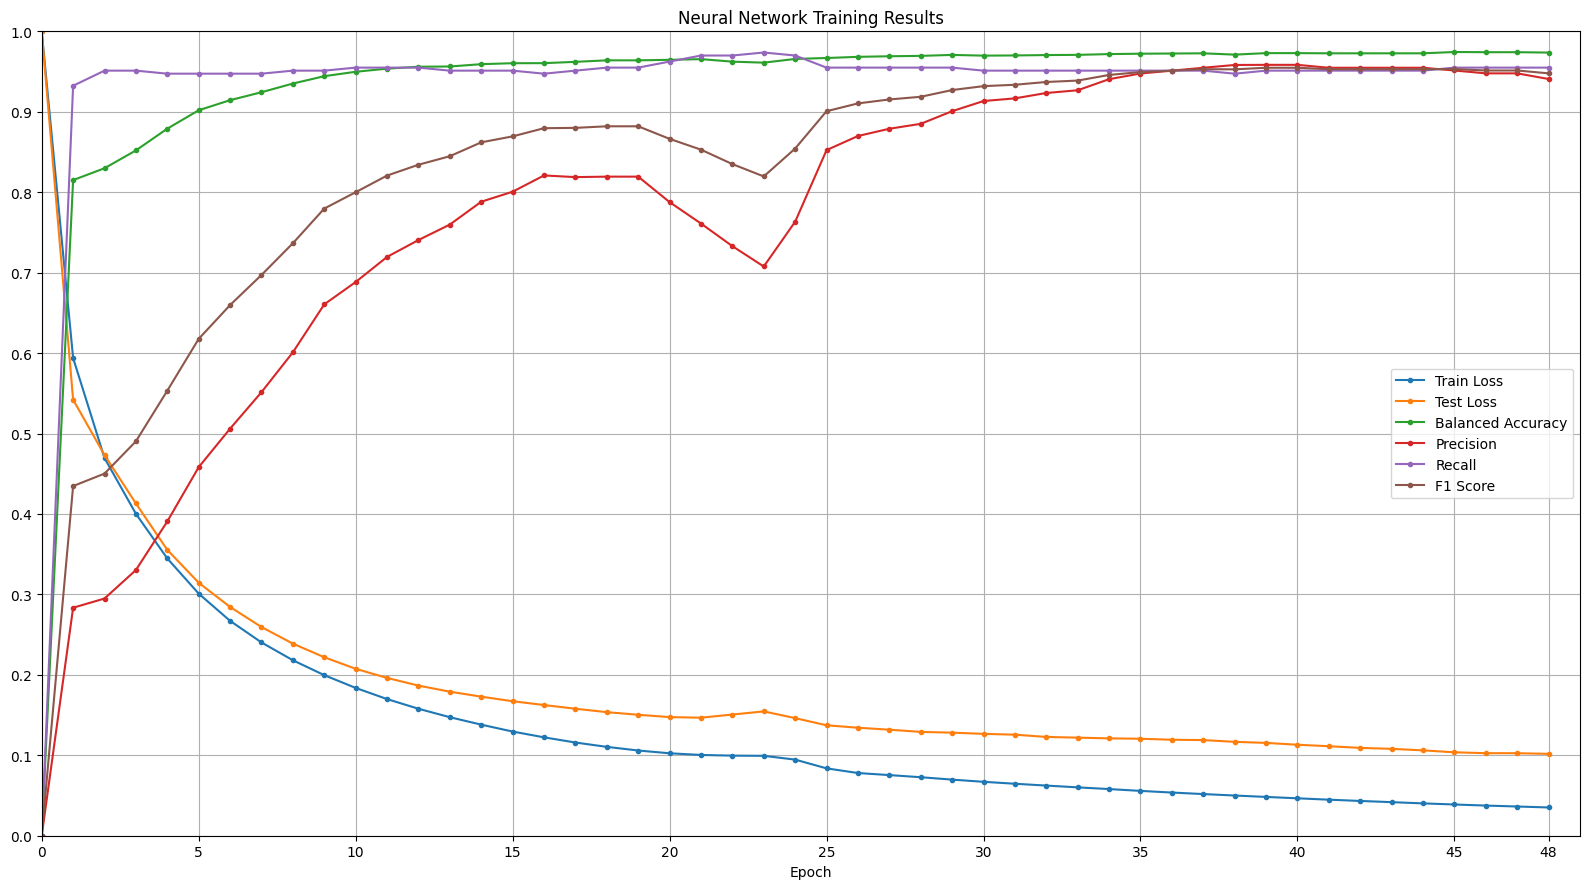

In [12]:
plt.figure(figsize=(16, 9))
plt.plot(plot_data["epoch"], plot_data["train_loss"], ".-", label="Train Loss")
plt.plot(plot_data["epoch"], plot_data["test_loss"], ".-", label="Test Loss")
# plt.plot(plot_data["epoch"], plot_data["accuracy"], ".-", label="Accuracy")
plt.plot(
    plot_data["epoch"], plot_data["balanced_accuracy"], ".-", label="Balanced Accuracy"
)
plt.plot(plot_data["epoch"], plot_data["precision"], ".-", label="Precision")
plt.plot(plot_data["epoch"], plot_data["recall"], ".-", label="Recall")
plt.plot(plot_data["epoch"], plot_data["f1-score"], ".-", label="F1 Score")
# plt.plot(plot_data["epoch"], plot_data["pr-auc"], ".-", label="Average Precision")
plt.xlim([0, len(plot_data["epoch"])])
plt.ylim([0, 1])
plt.xticks(np.append(np.arange(0, len(plot_data["epoch"]), 5), plot_data["epoch"][-1]))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend() 
plt.grid()
plt.title("Neural Network Training Results")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()
plt.close()